In [4]:
import pandas as pd
import numpy as np
import shutil
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [6]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [7]:
BASE_DIR = Path("/content/gdrive/MyDrive/rostat")

PRICE_DIR = BASE_DIR / "processed"
SALES_DIR = BASE_DIR / "processed_sales"

OUTPUT_DIR = BASE_DIR / "quarterly_model_selection_staged"

DO_CLEANUP = True

if DO_CLEANUP and OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
    print("Удалена старая папка:", OUTPUT_DIR)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Папка результатов:", OUTPUT_DIR)

Удалена старая папка: /content/gdrive/MyDrive/rostat/quarterly_model_selection_staged
Папка результатов: /content/gdrive/MyDrive/rostat/quarterly_model_selection_staged


In [8]:
prices_long = pd.read_csv(
    PRICE_DIR / "weekly_prices_long.csv",
    parse_dates=["date"]
)

products = pd.read_csv(
    PRICE_DIR / "product_dictionary.csv"
)

sales_group_long = pd.read_csv(
    SALES_DIR / "sales_dynamics_by_existing_categories.csv",
    parse_dates=["period_end"]
)

prices = prices_long.merge(
    products[
        [
            "product_code",
            "product_group_code",
            "product_group_name"
        ]
    ],
    on="product_code",
    how="left"
)

prices["period_end"] = (
    prices["date"]
    .dt.to_period("Q")
    .dt.to_timestamp(how="end")
    .dt.normalize()
)

prices["year"] = prices["period_end"].dt.year
prices["quarter"] = prices["period_end"].dt.quarter

price_quarter = (
    prices
    .groupby(
        [
            "period_end",
            "year",
            "quarter",
            "product_group_code",
            "product_group_name"
        ],
        as_index=False
    )
    .agg(
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        n_price_products=("product_code", "nunique"),
        n_price_observations=("price", "size")
    )
)

sales_group_long["period_end"] = (
    pd.to_datetime(sales_group_long["period_end"])
    .dt.normalize()
)

sales_group_long["year"] = sales_group_long["period_end"].dt.year
sales_group_long["quarter"] = sales_group_long["period_end"].dt.quarter

sales_quarter = (
    sales_group_long
    .groupby(
        [
            "period_end",
            "year",
            "quarter",
            "product_group_code",
            "product_group_name"
        ],
        as_index=False
    )
    .agg(
        sales_quarter_thousand_rub=("sales_quarter_thousand_rub", "sum"),
        sales_cumulative_thousand_rub=("sales_cumulative_thousand_rub", "sum"),
        n_sales_products=("n_sales_products", "max")
    )
)

print("Цены:", price_quarter["period_end"].min(), "—", price_quarter["period_end"].max())
print("Продажи:", sales_quarter["period_end"].min(), "—", sales_quarter["period_end"].max())

Цены: 2016-03-31 00:00:00 — 2025-12-31 00:00:00
Продажи: 2017-03-31 00:00:00 — 2025-12-31 00:00:00


In [10]:
all_groups = (
    price_quarter[
        [
            "product_group_code",
            "product_group_name"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

full_quarters = (
    pd.period_range(
        start="2016Q1",
        end="2025Q4",
        freq="Q"
    )
    .to_timestamp(how="end")
    .normalize()
)

full_grid = (
    all_groups
    .assign(key=1)
    .merge(
        pd.DataFrame(
            {
                "period_end": full_quarters,
                "key": 1
            }
        ),
        on="key",
        how="outer"
    )
    .drop(columns="key")
)

full_grid["year"] = full_grid["period_end"].dt.year
full_grid["quarter"] = full_grid["period_end"].dt.quarter

quarterly_data = full_grid.merge(
    price_quarter,
    on=[
        "period_end",
        "year",
        "quarter",
        "product_group_code",
        "product_group_name"
    ],
    how="left"
)

quarterly_data = quarterly_data.merge(
    sales_quarter,
    on=[
        "period_end",
        "year",
        "quarter",
        "product_group_code",
        "product_group_name"
    ],
    how="left"
)

quarterly_data = quarterly_data.sort_values(
    [
        "product_group_code",
        "period_end"
    ]
).reset_index(drop=True)

quarterly_data["sales_is_observed"] = (
    quarterly_data["sales_quarter_thousand_rub"].notna()
)

In [9]:
def make_index_from_first_valid(x):
    x = x.astype(float)
    first_valid = x.dropna()

    if len(first_valid) == 0:
        return pd.Series(np.nan, index=x.index)

    base_value = first_valid.iloc[0]

    if base_value == 0:
        return pd.Series(np.nan, index=x.index)

    return x / base_value * 100

In [11]:
quarterly_data["price_index"] = (
    quarterly_data
    .groupby("product_group_code")["median_price"]
    .transform(make_index_from_first_valid)
)

quarterly_data["sales_index"] = (
    quarterly_data
    .groupby("product_group_code")["sales_quarter_thousand_rub"]
    .transform(make_index_from_first_valid)
)

quarterly_data = quarterly_data.sort_values(
    [
        "product_group_code",
        "period_end"
    ]
).reset_index(drop=True)

quarterly_data["price_index_lag1"] = (
    quarterly_data
    .groupby("product_group_code")["price_index"]
    .shift(1)
)

quarterly_data["price_index_lag4"] = (
    quarterly_data
    .groupby("product_group_code")["price_index"]
    .shift(4)
)

quarterly_data["price_growth_qoq"] = (
    quarterly_data
    .groupby("product_group_code")["price_index"]
    .pct_change(1) * 100
)

quarterly_data["price_growth_yoy"] = (
    quarterly_data
    .groupby("product_group_code")["price_index"]
    .pct_change(4) * 100
)

quarterly_data["price_growth_qoq_lag1"] = (
    quarterly_data
    .groupby("product_group_code")["price_growth_qoq"]
    .shift(1)
)

quarterly_data["price_growth_yoy_lag1"] = (
    quarterly_data
    .groupby("product_group_code")["price_growth_yoy"]
    .shift(1)
)

quarterly_data["quarter_sin"] = np.sin(
    2 * np.pi * quarterly_data["quarter"] / 4
)

quarterly_data["quarter_cos"] = np.cos(
    2 * np.pi * quarterly_data["quarter"] / 4
)

quarterly_data.head()

,product_group_code,product_group_name,period_end,year,quarter,mean_price,median_price,n_price_products,n_price_observations,sales_quarter_thousand_rub,...,price_index,sales_index,price_index_lag1,price_index_lag4,price_growth_qoq,price_growth_yoy,price_growth_qoq_lag1,price_growth_yoy_lag1,quarter_sin,quarter_cos
0,G01,"Хлеб, крупы, мука и макаронные изделия",2016-03-31,2016,1,65.201042,65.570,8.0,96.0,NaN,...,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,6.123234e-17
1,G01,"Хлеб, крупы, мука и макаронные изделия",2016-06-30,2016,2,67.253462,66.090,8.0,104.0,NaN,...,100.793046,NaN,100.000000,NaN,0.793046,NaN,NaN,NaN,1.224647e-16,-1.000000e+00
2,G01,"Хлеб, крупы, мука и макаронные изделия",2016-09-30,2016,3,68.782788,66.115,8.0,104.0,NaN,...,100.831173,NaN,100.793046,NaN,0.037827,NaN,0.793046,NaN,-1.000000e+00,-1.836970e-16
3,G01,"Хлеб, крупы, мука и макаронные изделия",2016-12-31,2016,4,68.152308,65.675,8.0,104.0,NaN,...,100.160134,NaN,100.831173,NaN,-0.665507,NaN,0.037827,NaN,-2.449294e-16,1.000000e+00
4,G01,"Хлеб, крупы, мука и макаронные изделия",2017-03-31,2017,1,67.500104,65.115,8.0,96.0,2.617199e+08,...,99.306085,100.0,100.160134,100.0,-0.852684,-0.693915,-0.665507,NaN,1.000000e+00,6.123234e-17


In [12]:
coverage_check = (
    quarterly_data
    .groupby(
        [
            "product_group_code",
            "product_group_name"
        ],
        as_index=False
    )
    .agg(
        total_quarters=("period_end", "nunique"),
        observed_sales_quarters=("sales_is_observed", "sum"),
        start_date=("period_end", "min"),
        end_date=("period_end", "max"),
        missing_sales=("sales_index", lambda x: x.isna().sum()),
        missing_price=("price_index", lambda x: x.isna().sum())
    )
)

display(coverage_check)

quarterly_data.to_csv(
    OUTPUT_DIR / "quarterly_model_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

,product_group_code,product_group_name,total_quarters,observed_sales_quarters,start_date,end_date,missing_sales,missing_price
0,G01,"Хлеб, крупы, мука и макаронные изделия",40,36,2016-03-31,2025-12-31,4,4
1,G02,Молочная продукция и яйца,40,36,2016-03-31,2025-12-31,4,4
2,G03,"Мясо, птица, рыба и колбасные изделия",40,36,2016-03-31,2025-12-31,4,4
3,G04,"Овощи, фрукты и картофель",40,36,2016-03-31,2025-12-31,4,4
4,G05,"Бакалея, масло, сахар, чай, соль",40,36,2016-03-31,2025-12-31,4,4
5,G07,"Товары для дома, гигиены и бытовая химия",40,36,2016-03-31,2025-12-31,4,4
6,G10,Топливо и транспортные товары,40,36,2016-03-31,2025-12-31,4,4
7,G11,Услуги,40,0,2016-03-31,2025-12-31,40,4
8,G99,Прочее,40,36,2016-03-31,2025-12-31,4,4


In [13]:
def mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    mask = y_true != 0

    return np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100


def smape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0

    return np.mean(
        np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]
    ) * 100


def calculate_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred)
    }

In [14]:
TARGET_COL = "sales_index"

MIN_TRAIN_OBS = 12
MAXITER = 150
BASELINE_MODEL_NAME = "Seasonal Mean"

In [15]:
def seasonal_mean_prediction(category_df, validation_period, y_col=TARGET_COL):
    df = category_df.copy().sort_values("period_end").reset_index(drop=True)

    val_mask = df["period_end"] == validation_period
    valid_row = df[val_mask].copy()

    if len(valid_row) != 1:
        raise ValueError("Validation period должен давать одну строку")

    validation_quarter = int(valid_row["quarter"].iloc[0])

    train_df = df[
        df[y_col].notna() &
        (~val_mask)
    ].copy()

    same_quarter_values = train_df.loc[
        train_df["quarter"] == validation_quarter,
        y_col
    ].dropna()

    if len(same_quarter_values) > 0:
        yhat = float(same_quarter_values.mean())
    else:
        yhat = float(train_df[y_col].mean())

    return yhat

In [16]:
def prepare_exog_for_category(df, exog_cols, train_mask):
    if len(exog_cols) == 0:
        return None

    exog = df[exog_cols].astype(float).copy()

    train_medians = exog.loc[train_mask, exog_cols].median()

    exog = exog.fillna(train_medians)
    exog = exog.ffill().bfill().fillna(0)

    exog_mean = exog.loc[train_mask, exog_cols].mean()
    exog_std = exog.loc[train_mask, exog_cols].std().replace(0, 1)

    exog_scaled = (exog - exog_mean) / exog_std

    return exog_scaled

In [17]:
def sarimax_leave_one_quarter_prediction(
    category_df,
    validation_period,
    config,
    y_col=TARGET_COL
):
    df = category_df.copy().sort_values("period_end").reset_index(drop=True)

    val_mask = df["period_end"] == validation_period

    if val_mask.sum() != 1:
        raise ValueError("Validation period должен давать одну строку")

    y_true = df.loc[val_mask, y_col].iloc[0]

    if pd.isna(y_true):
        raise ValueError("В validation нет фактического значения")

    train_mask = df[y_col].notna() & (~val_mask)

    if train_mask.sum() < MIN_TRAIN_OBS:
        raise ValueError("Слишком мало train-наблюдений")

    y_for_model = df[y_col].copy()
    y_for_model.loc[val_mask] = np.nan

    y_for_model_log = np.log1p(y_for_model)

    exog_cols = config["exog_cols"]

    exog_scaled = prepare_exog_for_category(
        df=df,
        exog_cols=exog_cols,
        train_mask=train_mask
    )

    model = SARIMAX(
        y_for_model_log,
        exog=exog_scaled,
        order=config["order"],
        seasonal_order=config["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False,
        missing="none"
    )

    result = model.fit(
        disp=False,
        maxiter=MAXITER
    )

    val_idx = int(np.where(val_mask.values)[0][0])

    pred_log = result.get_prediction(
        start=val_idx,
        end=val_idx
    ).predicted_mean

    if hasattr(pred_log, "iloc"):
        pred_log_value = float(pred_log.iloc[0])
    else:
        pred_log_value = float(np.asarray(pred_log)[0])

    yhat = np.expm1(pred_log_value)

    if not np.isfinite(yhat):
        raise ValueError("Прогноз не finite")

    yhat = max(yhat, 0)

    return yhat, result.aic, result.bic

In [18]:
VALIDATION_START = "2019-03-31"
def run_leave_one_quarter_cv(
    configs,
    dataset,
    target_col=TARGET_COL,
    validation_start=None
):
    all_metrics = []
    all_predictions = []
    error_rows = []

    if validation_start is not None:
        validation_start = pd.Timestamp(validation_start)

    for group_code, category_df in dataset.groupby("product_group_code"):
        category_df = category_df.sort_values("period_end").reset_index(drop=True)
        group_name = category_df["product_group_name"].iloc[0]

        validation_mask = category_df[target_col].notna()

        if validation_start is not None:
            validation_mask = validation_mask & (
                category_df["period_end"] >= validation_start
            )

        validation_periods = (
            category_df.loc[validation_mask, "period_end"]
            .drop_duplicates()
            .sort_values()
            .tolist()
        )

        print("=" * 100)
        print(f"Категория: {group_code} — {group_name}")
        print("Доступных validation-кварталов:", len(validation_periods))

        for validation_period in validation_periods:
            valid_row = category_df[
                category_df["period_end"] == validation_period
            ].iloc[0]

            y_true = float(valid_row[target_col])

            for config in configs:
                try:
                    if config["model"] == BASELINE_MODEL_NAME:
                        yhat = seasonal_mean_prediction(
                            category_df,
                            validation_period,
                            y_col=target_col
                        )
                        aic = np.nan
                        bic = np.nan
                    else:
                        yhat, aic, bic = sarimax_leave_one_quarter_prediction(
                            category_df=category_df,
                            validation_period=validation_period,
                            config=config,
                            y_col=target_col
                        )

                    metrics = calculate_metrics([y_true], [yhat])

                    train_observations = category_df[
                        category_df[target_col].notna() &
                        (category_df["period_end"] != validation_period)
                    ]

                    all_metrics.append({
                        "target": target_col,
                        "product_group_code": group_code,
                        "product_group_name": group_name,
                        "validation_period": validation_period,
                        "validation_year": int(valid_row["year"]),
                        "validation_quarter": int(valid_row["quarter"]),
                        "model_id": config["model_id"],
                        "model": config["model"],
                        "model_type": config["model_type"],
                        "feature_set": config["feature_set"],
                        "order": str(config["order"]),
                        "seasonal_order": str(config["seasonal_order"]),
                        "exog_cols": ", ".join(config["exog_cols"]),
                        "train_n": len(train_observations),
                        "train_start": train_observations["period_end"].min(),
                        "train_end": train_observations["period_end"].max(),
                        "AIC": aic,
                        "BIC": bic,
                        **metrics
                    })

                    all_predictions.append({
                        "target": target_col,
                        "product_group_code": group_code,
                        "product_group_name": group_name,
                        "period_end": validation_period,
                        "year": int(valid_row["year"]),
                        "quarter": int(valid_row["quarter"]),
                        "model_id": config["model_id"],
                        "model": config["model"],
                        "model_type": config["model_type"],
                        "feature_set": config["feature_set"],
                        "y": y_true,
                        "yhat": yhat,
                        "abs_error": abs(y_true - yhat),
                        "pct_error": abs(y_true - yhat) / y_true * 100 if y_true != 0 else np.nan
                    })

                except Exception as e:
                    error_rows.append({
                        "product_group_code": group_code,
                        "product_group_name": group_name,
                        "validation_period": validation_period,
                        "model": config["model"],
                        "error": str(e)
                    })

    return (
        pd.DataFrame(all_metrics),
        pd.DataFrame(all_predictions),
        pd.DataFrame(error_rows)
    )

In [19]:
sarima_orders = [
    (0, 1, 0),
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1),
]

seasonal_orders = [
    (0, 1, 0, 4),
    (0, 1, 1, 4),
    (1, 1, 0, 4),
    (1, 1, 1, 4),
]

candidate_features = [
    "price_index_lag1",
    "price_index_lag4",
    "price_growth_qoq_lag1",
    "price_growth_yoy_lag1",
    "quarter_sin",
    "quarter_cos",
]

candidate_features = [
    col for col in candidate_features
    if col in quarterly_data.columns
]

print("Доступные признаки:")
print(candidate_features)

Доступные признаки:
['price_index_lag1', 'price_index_lag4', 'price_growth_qoq_lag1', 'price_growth_yoy_lag1', 'quarter_sin', 'quarter_cos']


In [20]:
def build_model_configs(
    feature_sets,
    sarima_orders_to_use,
    seasonal_orders_to_use,
    include_baseline=True,
    include_sarima=True,
    include_sarimax=True,
    id_prefix="M"
):
    configs = []

    if include_baseline:
        configs.append(
            {
                "model": "Seasonal Mean",
                "model_type": "Baseline",
                "feature_set": "none",
                "order": None,
                "seasonal_order": None,
                "exog_cols": []
            }
        )

    if include_sarima:
        for order in sarima_orders_to_use:
            for seasonal_order in seasonal_orders_to_use:
                configs.append(
                    {
                        "model": f"SARIMA {order}{seasonal_order}",
                        "model_type": "SARIMA",
                        "feature_set": "none",
                        "order": order,
                        "seasonal_order": seasonal_order,
                        "exog_cols": []
                    }
                )

    if include_sarimax:
        for order in sarima_orders_to_use:
            for seasonal_order in seasonal_orders_to_use:
                for features in feature_sets:
                    feature_set_name = " + ".join(features)

                    configs.append(
                        {
                            "model": f"SARIMAX {order}{seasonal_order} + {feature_set_name}",
                            "model_type": "SARIMAX",
                            "feature_set": feature_set_name,
                            "order": order,
                            "seasonal_order": seasonal_order,
                            "exog_cols": features
                        }
                    )

    for i, cfg in enumerate(configs):
        cfg["model_id"] = f"{id_prefix}{str(i).zfill(5)}"

    return configs

In [21]:
def summarize_models(metrics_df):
    summary = (
        metrics_df
        .groupby(
            [
                "model_id",
                "model",
                "model_type",
                "feature_set",
                "order",
                "seasonal_order",
                "exog_cols"
            ],
            as_index=False
        )
        .agg(
            mean_MAE=("MAE", "mean"),
            mean_RMSE=("RMSE", "mean"),
            mean_MAPE=("MAPE", "mean"),
            mean_sMAPE=("sMAPE", "mean"),
            median_MAPE=("MAPE", "median"),
            std_MAPE=("MAPE", "std"),
            min_MAPE=("MAPE", "min"),
            max_MAPE=("MAPE", "max"),
            n_runs=("MAPE", "size"),
            n_categories=("product_group_code", "nunique"),
            n_periods=("validation_period", "nunique")
        )
        .sort_values("mean_MAPE")
        .reset_index(drop=True)
    )

    return summary

In [22]:
stage0_configs = build_model_configs(
    feature_sets=[],
    sarima_orders_to_use=sarima_orders,
    seasonal_orders_to_use=seasonal_orders,
    include_baseline=True,
    include_sarima=True,
    include_sarimax=False,
    id_prefix="S0_"
)

print("Stage 0 моделей:", len(stage0_configs))

Stage 0 моделей: 17


In [23]:
stage0_metrics_df, stage0_predictions_df, stage0_errors_df = run_leave_one_quarter_cv(
    configs=stage0_configs,
    dataset=quarterly_data,
    target_col=TARGET_COL,
    validation_start=VALIDATION_START
)

stage0_summary = summarize_models(stage0_metrics_df)

display(stage0_summary.round(3))

Категория: G01 — Хлеб, крупы, мука и макаронные изделия
Доступных validation-кварталов: 28
Категория: G02 — Молочная продукция и яйца
Доступных validation-кварталов: 28
Категория: G03 — Мясо, птица, рыба и колбасные изделия
Доступных validation-кварталов: 28
Категория: G04 — Овощи, фрукты и картофель
Доступных validation-кварталов: 28
Категория: G05 — Бакалея, масло, сахар, чай, соль
Доступных validation-кварталов: 28
Категория: G07 — Товары для дома, гигиены и бытовая химия
Доступных validation-кварталов: 28
Категория: G10 — Топливо и транспортные товары
Доступных validation-кварталов: 28
Категория: G11 — Услуги
Доступных validation-кварталов: 0
Категория: G99 — Прочее
Доступных validation-кварталов: 28


,model_id,model,model_type,feature_set,order,seasonal_order,exog_cols,mean_MAE,mean_RMSE,mean_MAPE,mean_sMAPE,median_MAPE,std_MAPE,min_MAPE,max_MAPE,n_runs,n_categories,n_periods
0,S0_00012,"SARIMA (0, 1, 1)(1, 1, 1, 4)",SARIMA,none,"(0, 1, 1)","(1, 1, 1, 4)",,10.102,10.102,6.322,6.305,4.160,7.628,0.003,61.313,224,8,28
1,S0_00010,"SARIMA (0, 1, 1)(0, 1, 1, 4)",SARIMA,none,"(0, 1, 1)","(0, 1, 1, 4)",,10.147,10.147,6.344,6.315,4.274,7.703,0.047,61.313,224,8,28
2,S0_00008,"SARIMA (1, 1, 0)(1, 1, 1, 4)",SARIMA,none,"(1, 1, 0)","(1, 1, 1, 4)",,10.174,10.174,6.359,6.355,4.410,7.351,0.034,61.331,224,8,28
3,S0_00004,"SARIMA (0, 1, 0)(1, 1, 1, 4)",SARIMA,none,"(0, 1, 0)","(1, 1, 1, 4)",,10.181,10.181,6.360,6.324,4.063,8.312,0.008,74.641,224,8,28
4,S0_00002,"SARIMA (0, 1, 0)(0, 1, 1, 4)",SARIMA,none,"(0, 1, 0)","(0, 1, 1, 4)",,10.255,10.255,6.406,6.370,4.062,8.311,0.007,74.832,224,8,28
5,S0_00006,"SARIMA (1, 1, 0)(0, 1, 1, 4)",SARIMA,none,"(1, 1, 0)","(0, 1, 1, 4)",,10.331,10.331,6.468,6.444,4.333,7.685,0.038,61.331,224,8,28
6,S0_00016,"SARIMA (1, 1, 1)(1, 1, 1, 4)",SARIMA,none,"(1, 1, 1)","(1, 1, 1, 4)",,11.454,11.454,6.946,7.388,4.316,9.695,0.005,100.000,224,8,28
7,S0_00014,"SARIMA (1, 1, 1)(0, 1, 1, 4)",SARIMA,none,"(1, 1, 1)","(0, 1, 1, 4)",,12.007,12.007,7.378,8.260,4.403,11.540,0.015,100.000,224,8,28
8,S0_00003,"SARIMA (0, 1, 0)(1, 1, 0, 4)",SARIMA,none,"(0, 1, 0)","(1, 1, 0, 4)",,12.465,12.465,8.054,7.795,3.941,14.272,0.038,141.223,224,8,28
9,S0_00011,"SARIMA (0, 1, 1)(1, 1, 0, 4)",SARIMA,none,"(0, 1, 1)","(1, 1, 0, 4)",,12.416,12.416,8.082,7.784,4.293,14.310,0.022,149.671,224,8,28


In [24]:
stage0_metrics_df.to_csv(
    OUTPUT_DIR / "stage0_sarima_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

stage0_predictions_df.to_csv(
    OUTPUT_DIR / "stage0_sarima_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

stage0_summary.to_csv(
    OUTPUT_DIR / "stage0_sarima_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

stage0_errors_df.to_csv(
    OUTPUT_DIR / "stage0_errors.csv",
    index=False,
    encoding="utf-8-sig"
)

In [25]:
TOP_N_SARIMA_STRUCTURES = 4

top_sarima_structures = (
    stage0_summary[
        stage0_summary["model_type"] == "SARIMA"
    ]
    .sort_values("mean_MAPE")
    .head(TOP_N_SARIMA_STRUCTURES)
    [
        [
            "order",
            "seasonal_order"
        ]
    ]
    .drop_duplicates()
)

def parse_tuple_string(value):
    if isinstance(value, tuple):
        return value

    value = str(value)
    value = value.replace("(", "").replace(")", "")
    parts = [int(x.strip()) for x in value.split(",")]
    return tuple(parts)

top_sarima_orders = []
top_seasonal_orders = []

for _, row in top_sarima_structures.iterrows():
    top_sarima_orders.append(parse_tuple_string(row["order"]))
    top_seasonal_orders.append(parse_tuple_string(row["seasonal_order"]))

top_pairs = list(zip(top_sarima_orders, top_seasonal_orders))

print("Лучшие SARIMA-структуры:")
for order, seasonal_order in top_pairs:
    print(order, seasonal_order)

Лучшие SARIMA-структуры:
(0, 1, 1) (1, 1, 1, 4)
(0, 1, 1) (0, 1, 1, 4)
(1, 1, 0) (1, 1, 1, 4)
(0, 1, 0) (1, 1, 1, 4)


In [26]:
def build_model_configs_from_pairs(
    feature_sets,
    order_pairs,
    include_baseline=True,
    include_sarima=True,
    include_sarimax=True,
    id_prefix="M"
):
    configs = []

    if include_baseline:
        configs.append(
            {
                "model": "Seasonal Mean",
                "model_type": "Baseline",
                "feature_set": "none",
                "order": None,
                "seasonal_order": None,
                "exog_cols": []
            }
        )

    if include_sarima:
        for order, seasonal_order in order_pairs:
            configs.append(
                {
                    "model": f"SARIMA {order}{seasonal_order}",
                    "model_type": "SARIMA",
                    "feature_set": "none",
                    "order": order,
                    "seasonal_order": seasonal_order,
                    "exog_cols": []
                }
            )

    if include_sarimax:
        for order, seasonal_order in order_pairs:
            for features in feature_sets:
                feature_set_name = " + ".join(features)

                configs.append(
                    {
                        "model": f"SARIMAX {order}{seasonal_order} + {feature_set_name}",
                        "model_type": "SARIMAX",
                        "feature_set": feature_set_name,
                        "order": order,
                        "seasonal_order": seasonal_order,
                        "exog_cols": features
                    }
                )

    for i, cfg in enumerate(configs):
        cfg["model_id"] = f"{id_prefix}{str(i).zfill(5)}"

    return configs

In [27]:
single_feature_sets = [
    [feature]
    for feature in candidate_features
]

stage1_configs = build_model_configs_from_pairs(
    feature_sets=single_feature_sets,
    order_pairs=top_pairs,
    include_baseline=True,
    include_sarima=True,
    include_sarimax=True,
    id_prefix="S1_"
)

print("Stage 1 моделей:", len(stage1_configs))

Stage 1 моделей: 29


In [28]:
stage1_metrics_df, stage1_predictions_df, stage1_errors_df = run_leave_one_quarter_cv(
    configs=stage1_configs,
    dataset=quarterly_data,
    target_col=TARGET_COL,
    validation_start=VALIDATION_START
)

stage1_summary = summarize_models(stage1_metrics_df)

display(stage1_summary.round(3))

Категория: G01 — Хлеб, крупы, мука и макаронные изделия
Доступных validation-кварталов: 28
Категория: G02 — Молочная продукция и яйца
Доступных validation-кварталов: 28
Категория: G03 — Мясо, птица, рыба и колбасные изделия
Доступных validation-кварталов: 28
Категория: G04 — Овощи, фрукты и картофель
Доступных validation-кварталов: 28
Категория: G05 — Бакалея, масло, сахар, чай, соль
Доступных validation-кварталов: 28
Категория: G07 — Товары для дома, гигиены и бытовая химия
Доступных validation-кварталов: 28
Категория: G10 — Топливо и транспортные товары
Доступных validation-кварталов: 28
Категория: G11 — Услуги
Доступных validation-кварталов: 0
Категория: G99 — Прочее
Доступных validation-кварталов: 28


,model_id,model,model_type,feature_set,order,seasonal_order,exog_cols,mean_MAE,mean_RMSE,mean_MAPE,mean_sMAPE,median_MAPE,std_MAPE,min_MAPE,max_MAPE,n_runs,n_categories,n_periods
0,S1_00014,"SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",SARIMAX,price_growth_yoy_lag1,"(0, 1, 1)","(0, 1, 1, 4)",price_growth_yoy_lag1,10.094,10.094,6.314,6.293,4.158,7.603,0.003,61.177,224,8,28
1,S1_00001,"SARIMA (0, 1, 1)(1, 1, 1, 4)",SARIMA,none,"(0, 1, 1)","(1, 1, 1, 4)",,10.102,10.102,6.322,6.305,4.160,7.628,0.003,61.313,224,8,28
2,S1_00013,"SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_q...",SARIMAX,price_growth_qoq_lag1,"(0, 1, 1)","(0, 1, 1, 4)",price_growth_qoq_lag1,10.026,10.026,6.325,6.242,4.085,8.403,0.015,74.974,224,8,28
3,S1_00010,"SARIMAX (0, 1, 1)(1, 1, 1, 4) + quarter_cos",SARIMAX,quarter_cos,"(0, 1, 1)","(1, 1, 1, 4)",quarter_cos,10.121,10.121,6.329,6.307,4.178,7.602,0.017,61.318,224,8,28
4,S1_00008,"SARIMAX (0, 1, 1)(1, 1, 1, 4) + price_growth_y...",SARIMAX,price_growth_yoy_lag1,"(0, 1, 1)","(1, 1, 1, 4)",price_growth_yoy_lag1,10.119,10.119,6.335,6.321,4.162,7.486,0.038,61.191,224,8,28
5,S1_00009,"SARIMAX (0, 1, 1)(1, 1, 1, 4) + quarter_sin",SARIMAX,quarter_sin,"(0, 1, 1)","(1, 1, 1, 4)",quarter_sin,10.133,10.133,6.340,6.313,4.151,7.685,0.020,61.313,224,8,28
6,S1_00015,"SARIMAX (0, 1, 1)(0, 1, 1, 4) + quarter_sin",SARIMAX,quarter_sin,"(0, 1, 1)","(0, 1, 1, 4)",quarter_sin,10.144,10.144,6.343,6.314,4.274,7.703,0.046,61.313,224,8,28
7,S1_00016,"SARIMAX (0, 1, 1)(0, 1, 1, 4) + quarter_cos",SARIMAX,quarter_cos,"(0, 1, 1)","(0, 1, 1, 4)",quarter_cos,10.144,10.144,6.343,6.314,4.271,7.703,0.046,61.313,224,8,28
8,S1_00002,"SARIMA (0, 1, 1)(0, 1, 1, 4)",SARIMA,none,"(0, 1, 1)","(0, 1, 1, 4)",,10.147,10.147,6.344,6.315,4.274,7.703,0.047,61.313,224,8,28
9,S1_00020,"SARIMAX (1, 1, 0)(1, 1, 1, 4) + price_growth_y...",SARIMAX,price_growth_yoy_lag1,"(1, 1, 0)","(1, 1, 1, 4)",price_growth_yoy_lag1,10.197,10.197,6.358,6.356,4.510,7.136,0.015,61.172,224,8,28


In [29]:
stage1_metrics_df.to_csv(
    OUTPUT_DIR / "stage1_single_features_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

stage1_predictions_df.to_csv(
    OUTPUT_DIR / "stage1_single_features_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

stage1_summary.to_csv(
    OUTPUT_DIR / "stage1_single_features_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

stage1_errors_df.to_csv(
    OUTPUT_DIR / "stage1_errors.csv",
    index=False,
    encoding="utf-8-sig"
)

OSError: Cannot save file into a non-existent directory: '/content/gdrive/MyDrive/rostat/quarterly_model_selection_staged'

In [ ]:
match_cols = [
    "target",
    "product_group_code",
    "validation_period",
    "order",
    "seasonal_order"
]

stage1_sarima_base = (
    stage1_metrics_df[
        stage1_metrics_df["model_type"] == "SARIMA"
    ][
        match_cols + ["MAPE", "sMAPE", "MAE", "RMSE"]
    ]
    .rename(
        columns={
            "MAPE": "sarima_base_MAPE",
            "sMAPE": "sarima_base_sMAPE",
            "MAE": "sarima_base_MAE",
            "RMSE": "sarima_base_RMSE"
        }
    )
)

stage1_sarimax = stage1_metrics_df[
    stage1_metrics_df["model_type"] == "SARIMAX"
].copy()

stage1_feature_contribution = stage1_sarimax.merge(
    stage1_sarima_base,
    on=match_cols,
    how="inner"
)

stage1_feature_contribution["feature_gain_pp"] = (
    stage1_feature_contribution["sarima_base_MAPE"]
    - stage1_feature_contribution["MAPE"]
)

stage1_feature_contribution["feature_improved"] = (
    stage1_feature_contribution["feature_gain_pp"] > 0
)

stage1_feature_summary = (
    stage1_feature_contribution
    .groupby("feature_set", as_index=False)
    .agg(
        mean_sarima_base_MAPE=("sarima_base_MAPE", "mean"),
        mean_sarimax_MAPE=("MAPE", "mean"),
        mean_feature_gain_pp=("feature_gain_pp", "mean"),
        median_feature_gain_pp=("feature_gain_pp", "median"),
        improved_share_percent=("feature_improved", lambda x: x.mean() * 100),
        n_runs=("MAPE", "size")
    )
    .sort_values("mean_feature_gain_pp", ascending=False)
    .reset_index(drop=True)
)

display(stage1_feature_summary.round(3))

,feature_set,mean_sarima_base_MAPE,mean_sarimax_MAPE,mean_feature_gain_pp,median_feature_gain_pp,improved_share_percent,n_runs
0,price_growth_yoy_lag1,6.346,6.344,0.002,-0.020,48.996,896
1,quarter_cos,6.346,6.356,-0.009,0.000,52.567,896
2,quarter_sin,6.346,6.358,-0.012,-0.000,49.219,896
3,price_index_lag1,6.346,6.410,-0.064,-0.036,47.210,896
4,price_growth_qoq_lag1,6.346,6.427,-0.081,0.011,51.339,896
5,price_index_lag4,6.346,6.470,-0.124,0.010,51.451,896


In [ ]:
stage1_feature_contribution.to_csv(
    OUTPUT_DIR / "stage1_feature_contribution.csv",
    index=False,
    encoding="utf-8-sig"
)

stage1_feature_summary.to_csv(
    OUTPUT_DIR / "stage1_feature_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
TOP_N_FEATURES = 3

top_features = (
    stage1_feature_summary
    .sort_values("mean_feature_gain_pp", ascending=False)
    .head(TOP_N_FEATURES)["feature_set"]
    .tolist()
)

print("Top признаки:")
print(top_features)

Top признаки:
['price_growth_yoy_lag1', 'quarter_cos', 'quarter_sin']


In [ ]:
if len(top_features) == 0:
    top_features = (
        stage1_summary[
            stage1_summary["model_type"] == "SARIMAX"
        ]
        .groupby("feature_set", as_index=False)
        .agg(best_MAPE=("mean_MAPE", "min"))
        .sort_values("best_MAPE")
        .head(TOP_N_FEATURES)["feature_set"]
        .tolist()
    )

print("Итоговые top_features:")
print(top_features)

Итоговые top_features:
['price_growth_yoy_lag1', 'quarter_cos', 'quarter_sin']


In [ ]:
final_feature_sets = []

for r in range(1, len(top_features) + 1):
    for combo in combinations(top_features, r):
        final_feature_sets.append(list(combo))

print("Финальные наборы признаков:")
for fs in final_feature_sets:
    print(fs)

Финальные наборы признаков:
['price_growth_yoy_lag1']
['quarter_cos']
['quarter_sin']
['price_growth_yoy_lag1', 'quarter_cos']
['price_growth_yoy_lag1', 'quarter_sin']
['quarter_cos', 'quarter_sin']
['price_growth_yoy_lag1', 'quarter_cos', 'quarter_sin']


In [ ]:
stage2_configs = build_model_configs_from_pairs(
    feature_sets=final_feature_sets,
    order_pairs=top_pairs,
    include_baseline=True,
    include_sarima=True,
    include_sarimax=True,
    id_prefix="S2_"
)

print("Stage 2 моделей:", len(stage2_configs))

Stage 2 моделей: 33


In [ ]:
stage2_metrics_df, stage2_predictions_df, stage2_errors_df = run_leave_one_quarter_cv(
    configs=stage2_configs,
    dataset=quarterly_data,
    target_col=TARGET_COL,
    validation_start=VALIDATION_START
)

stage2_summary = summarize_models(stage2_metrics_df)

display(stage2_summary.round(3))

Категория: G01 — Хлеб, крупы, мука и макаронные изделия
Доступных validation-кварталов: 28
Категория: G02 — Молочная продукция и яйца
Доступных validation-кварталов: 28
Категория: G03 — Мясо, птица, рыба и колбасные изделия
Доступных validation-кварталов: 28
Категория: G04 — Овощи, фрукты и картофель
Доступных validation-кварталов: 28
Категория: G05 — Бакалея, масло, сахар, чай, соль
Доступных validation-кварталов: 28
Категория: G07 — Товары для дома, гигиены и бытовая химия
Доступных validation-кварталов: 28
Категория: G10 — Топливо и транспортные товары
Доступных validation-кварталов: 28
Категория: G11 — Услуги
Доступных validation-кварталов: 0
Категория: G99 — Прочее
Доступных validation-кварталов: 28


,model_id,model,model_type,feature_set,order,seasonal_order,exog_cols,mean_MAE,mean_RMSE,mean_MAPE,mean_sMAPE,median_MAPE,std_MAPE,min_MAPE,max_MAPE,n_runs,n_categories,n_periods
0,S2_00016,"SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",SARIMAX,price_growth_yoy_lag1 + quarter_sin,"(0, 1, 1)","(0, 1, 1, 4)","price_growth_yoy_lag1, quarter_sin",10.094,10.094,6.314,6.292,4.159,7.602,0.003,61.177,224,8,28
1,S2_00012,"SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",SARIMAX,price_growth_yoy_lag1,"(0, 1, 1)","(0, 1, 1, 4)",price_growth_yoy_lag1,10.094,10.094,6.314,6.293,4.158,7.603,0.003,61.177,224,8,28
2,S2_00015,"SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",SARIMAX,price_growth_yoy_lag1 + quarter_cos,"(0, 1, 1)","(0, 1, 1, 4)","price_growth_yoy_lag1, quarter_cos",10.095,10.095,6.314,6.293,4.159,7.602,0.002,61.177,224,8,28
3,S2_00018,"SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",SARIMAX,price_growth_yoy_lag1 + quarter_cos + quarter_sin,"(0, 1, 1)","(0, 1, 1, 4)","price_growth_yoy_lag1, quarter_cos, quarter_sin",10.096,10.096,6.315,6.293,4.158,7.602,0.001,61.177,224,8,28
4,S2_00010,"SARIMAX (0, 1, 1)(1, 1, 1, 4) + quarter_cos + ...",SARIMAX,quarter_cos + quarter_sin,"(0, 1, 1)","(1, 1, 1, 4)","quarter_cos, quarter_sin",10.101,10.101,6.318,6.299,4.177,7.640,0.009,61.315,224,8,28
5,S2_00001,"SARIMA (0, 1, 1)(1, 1, 1, 4)",SARIMA,none,"(0, 1, 1)","(1, 1, 1, 4)",,10.102,10.102,6.322,6.305,4.160,7.628,0.003,61.313,224,8,28
6,S2_00006,"SARIMAX (0, 1, 1)(1, 1, 1, 4) + quarter_cos",SARIMAX,quarter_cos,"(0, 1, 1)","(1, 1, 1, 4)",quarter_cos,10.121,10.121,6.329,6.307,4.178,7.602,0.017,61.318,224,8,28
7,S2_00005,"SARIMAX (0, 1, 1)(1, 1, 1, 4) + price_growth_y...",SARIMAX,price_growth_yoy_lag1,"(0, 1, 1)","(1, 1, 1, 4)",price_growth_yoy_lag1,10.119,10.119,6.335,6.321,4.162,7.486,0.038,61.191,224,8,28
8,S2_00007,"SARIMAX (0, 1, 1)(1, 1, 1, 4) + quarter_sin",SARIMAX,quarter_sin,"(0, 1, 1)","(1, 1, 1, 4)",quarter_sin,10.133,10.133,6.340,6.313,4.151,7.685,0.020,61.313,224,8,28
9,S2_00017,"SARIMAX (0, 1, 1)(0, 1, 1, 4) + quarter_cos + ...",SARIMAX,quarter_cos + quarter_sin,"(0, 1, 1)","(0, 1, 1, 4)","quarter_cos, quarter_sin",10.144,10.144,6.343,6.313,4.274,7.703,0.047,61.313,224,8,28


In [ ]:
stage2_metrics_df.to_csv(
    OUTPUT_DIR / "stage2_top_features_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

stage2_predictions_df.to_csv(
    OUTPUT_DIR / "stage2_top_features_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

stage2_summary.to_csv(
    OUTPUT_DIR / "stage2_top_features_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

stage2_errors_df.to_csv(
    OUTPUT_DIR / "stage2_errors.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
stage2_sarima_base = (
    stage2_metrics_df[
        stage2_metrics_df["model_type"] == "SARIMA"
    ][
        match_cols + ["MAPE", "sMAPE", "MAE", "RMSE"]
    ]
    .rename(
        columns={
            "MAPE": "sarima_base_MAPE",
            "sMAPE": "sarima_base_sMAPE",
            "MAE": "sarima_base_MAE",
            "RMSE": "sarima_base_RMSE"
        }
    )
)

stage2_sarimax = stage2_metrics_df[
    stage2_metrics_df["model_type"] == "SARIMAX"
].copy()

stage2_feature_contribution = stage2_sarimax.merge(
    stage2_sarima_base,
    on=match_cols,
    how="inner"
)

stage2_feature_contribution["feature_gain_pp"] = (
    stage2_feature_contribution["sarima_base_MAPE"]
    - stage2_feature_contribution["MAPE"]
)

stage2_feature_contribution["feature_improved"] = (
    stage2_feature_contribution["feature_gain_pp"] > 0
)

stage2_feature_summary = (
    stage2_feature_contribution
    .groupby("feature_set", as_index=False)
    .agg(
        mean_sarima_base_MAPE=("sarima_base_MAPE", "mean"),
        mean_sarimax_MAPE=("MAPE", "mean"),
        mean_feature_gain_pp=("feature_gain_pp", "mean"),
        median_feature_gain_pp=("feature_gain_pp", "median"),
        improved_share_percent=("feature_improved", lambda x: x.mean() * 100),
        n_runs=("MAPE", "size")
    )
    .sort_values("mean_feature_gain_pp", ascending=False)
    .reset_index(drop=True)
)

display(stage2_feature_summary.round(3))

,feature_set,mean_sarima_base_MAPE,mean_sarimax_MAPE,mean_feature_gain_pp,median_feature_gain_pp,improved_share_percent,n_runs
0,price_growth_yoy_lag1,6.346,6.344,0.002,-0.020,48.996,896
1,quarter_cos + quarter_sin,6.346,6.346,0.000,-0.000,48.549,896
2,price_growth_yoy_lag1 + quarter_cos,6.346,6.346,0.000,-0.012,48.661,896
3,price_growth_yoy_lag1 + quarter_sin,6.346,6.348,-0.001,-0.014,49.107,896
4,quarter_cos,6.346,6.356,-0.009,0.000,52.567,896
5,quarter_sin,6.346,6.358,-0.012,-0.000,49.219,896
6,price_growth_yoy_lag1 + quarter_cos + quarter_sin,6.346,6.360,-0.013,-0.020,48.326,896


In [ ]:
stage2_feature_contribution.to_csv(
    OUTPUT_DIR / "stage2_feature_contribution.csv",
    index=False,
    encoding="utf-8-sig"
)

stage2_feature_summary.to_csv(
    OUTPUT_DIR / "stage2_feature_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
ALLOW_BASELINE_AS_FINAL = False

if ALLOW_BASELINE_AS_FINAL:
    final_candidates = stage2_summary.copy()
else:
    final_candidates = stage2_summary[
        stage2_summary["model_type"] != "Baseline"
    ].copy()

best_model_row = final_candidates.sort_values("mean_MAPE").iloc[0]

display(best_model_row.to_frame().T)

BEST_MODEL_ID = best_model_row["model_id"]
BEST_MODEL_NAME = best_model_row["model"]

best_config = next(
    cfg for cfg in stage2_configs
    if cfg["model_id"] == BEST_MODEL_ID
)

print("Лучшая модель:")
print(BEST_MODEL_NAME)

print("\nТип модели:")
print(best_config["model_type"])

print("\norder:")
print(best_config["order"])

print("\nseasonal_order:")
print(best_config["seasonal_order"])

print("\nПризнаки:")
print(best_config["exog_cols"])

,model_id,model,model_type,feature_set,order,seasonal_order,exog_cols,mean_MAE,mean_RMSE,mean_MAPE,mean_sMAPE,median_MAPE,std_MAPE,min_MAPE,max_MAPE,n_runs,n_categories,n_periods
0,S2_00016,"SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",SARIMAX,price_growth_yoy_lag1 + quarter_sin,"(0, 1, 1)","(0, 1, 1, 4)","price_growth_yoy_lag1, quarter_sin",10.093539,10.093539,6.313757,6.292093,4.158932,7.6025,0.003295,61.177313,224,8,28


Лучшая модель:
SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_yoy_lag1 + quarter_sin

Тип модели:
SARIMAX

order:
(0, 1, 1)

seasonal_order:
(0, 1, 1, 4)

Признаки:
['price_growth_yoy_lag1', 'quarter_sin']


In [ ]:
best_model_info = pd.DataFrame(
    [
        {
            "best_model_id": BEST_MODEL_ID,
            "best_model": BEST_MODEL_NAME,
            "model_type": best_config["model_type"],
            "feature_set": best_config["feature_set"],
            "order": str(best_config["order"]),
            "seasonal_order": str(best_config["seasonal_order"]),
            "exog_cols": ", ".join(best_config["exog_cols"]),
            "mean_MAE": best_model_row["mean_MAE"],
            "mean_RMSE": best_model_row["mean_RMSE"],
            "mean_MAPE": best_model_row["mean_MAPE"],
            "mean_sMAPE": best_model_row["mean_sMAPE"],
            "median_MAPE": best_model_row["median_MAPE"],
            "std_MAPE": best_model_row["std_MAPE"],
            "n_runs": best_model_row["n_runs"],
            "n_categories": best_model_row["n_categories"],
            "n_periods": best_model_row["n_periods"]
        }
    ]
)

display(best_model_info.round(3))

best_model_info.to_csv(
    OUTPUT_DIR / "best_model_info.csv",
    index=False,
    encoding="utf-8-sig"
)

,best_model_id,best_model,model_type,feature_set,order,seasonal_order,exog_cols,mean_MAE,mean_RMSE,mean_MAPE,mean_sMAPE,median_MAPE,std_MAPE,n_runs,n_categories,n_periods
0,S2_00016,"SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",SARIMAX,price_growth_yoy_lag1 + quarter_sin,"(0, 1, 1)","(0, 1, 1, 4)","price_growth_yoy_lag1, quarter_sin",10.094,10.094,6.314,6.292,4.159,7.602,224,8,28


In [ ]:
stage3_metrics_df, stage3_predictions_df, stage3_errors_df = run_leave_one_quarter_cv(
    configs=[best_config],
    dataset=quarterly_data,
    target_col=TARGET_COL,
    validation_start=VALIDATION_START
)

stage3_summary = summarize_models(stage3_metrics_df)

display(stage3_summary.round(3))

Категория: G01 — Хлеб, крупы, мука и макаронные изделия
Доступных validation-кварталов: 28
Категория: G02 — Молочная продукция и яйца
Доступных validation-кварталов: 28
Категория: G03 — Мясо, птица, рыба и колбасные изделия
Доступных validation-кварталов: 28
Категория: G04 — Овощи, фрукты и картофель
Доступных validation-кварталов: 28
Категория: G05 — Бакалея, масло, сахар, чай, соль
Доступных validation-кварталов: 28
Категория: G07 — Товары для дома, гигиены и бытовая химия
Доступных validation-кварталов: 28
Категория: G10 — Топливо и транспортные товары
Доступных validation-кварталов: 28
Категория: G11 — Услуги
Доступных validation-кварталов: 0
Категория: G99 — Прочее
Доступных validation-кварталов: 28


,model_id,model,model_type,feature_set,order,seasonal_order,exog_cols,mean_MAE,mean_RMSE,mean_MAPE,mean_sMAPE,median_MAPE,std_MAPE,min_MAPE,max_MAPE,n_runs,n_categories,n_periods
0,S2_00016,"SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",SARIMAX,price_growth_yoy_lag1 + quarter_sin,"(0, 1, 1)","(0, 1, 1, 4)","price_growth_yoy_lag1, quarter_sin",10.094,10.094,6.314,6.292,4.159,7.602,0.003,61.177,224,8,28


In [ ]:
stage3_metrics_df.to_csv(
    OUTPUT_DIR / "stage3_best_model_only_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

stage3_predictions_df.to_csv(
    OUTPUT_DIR / "stage3_best_model_only_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

stage3_summary.to_csv(
    OUTPUT_DIR / "stage3_best_model_only_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

stage3_errors_df.to_csv(
    OUTPUT_DIR / "stage3_errors.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
stage_comparison = pd.concat(
    [
        stage0_summary.assign(stage="Stage 0: SARIMA only"),
        stage1_summary.assign(stage="Stage 1: single features"),
        stage2_summary.assign(stage="Stage 2: top feature combinations"),
        stage3_summary.assign(stage="Stage 3: best model only")
    ],
    ignore_index=True
)

stage_best_summary = (
    stage_comparison
    .sort_values(["stage", "mean_MAPE"])
    .groupby("stage")
    .head(5)
    .reset_index(drop=True)
)

display(
    stage_best_summary[
        [
            "stage",
            "model",
            "model_type",
            "feature_set",
            "mean_MAE",
            "mean_RMSE",
            "mean_MAPE",
            "mean_sMAPE",
            "median_MAPE",
            "std_MAPE",
            "n_runs"
        ]
    ].round(3)
)

stage_comparison.to_csv(
    OUTPUT_DIR / "all_stages_model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

stage_best_summary.to_csv(
    OUTPUT_DIR / "best_models_by_stage.csv",
    index=False,
    encoding="utf-8-sig"
)

,stage,model,model_type,feature_set,mean_MAE,mean_RMSE,mean_MAPE,mean_sMAPE,median_MAPE,std_MAPE,n_runs
0,Stage 0: SARIMA only,"SARIMA (0, 1, 1)(1, 1, 1, 4)",SARIMA,none,10.102,10.102,6.322,6.305,4.160,7.628,224
1,Stage 0: SARIMA only,"SARIMA (0, 1, 1)(0, 1, 1, 4)",SARIMA,none,10.147,10.147,6.344,6.315,4.274,7.703,224
2,Stage 0: SARIMA only,"SARIMA (1, 1, 0)(1, 1, 1, 4)",SARIMA,none,10.174,10.174,6.359,6.355,4.410,7.351,224
3,Stage 0: SARIMA only,"SARIMA (0, 1, 0)(1, 1, 1, 4)",SARIMA,none,10.181,10.181,6.360,6.324,4.063,8.312,224
4,Stage 0: SARIMA only,"SARIMA (0, 1, 0)(0, 1, 1, 4)",SARIMA,none,10.255,10.255,6.406,6.370,4.062,8.311,224
5,Stage 1: single features,"SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",SARIMAX,price_growth_yoy_lag1,10.094,10.094,6.314,6.293,4.158,7.603,224
6,Stage 1: single features,"SARIMA (0, 1, 1)(1, 1, 1, 4)",SARIMA,none,10.102,10.102,6.322,6.305,4.160,7.628,224
7,Stage 1: single features,"SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_q...",SARIMAX,price_growth_qoq_lag1,10.026,10.026,6.325,6.242,4.085,8.403,224
8,Stage 1: single features,"SARIMAX (0, 1, 1)(1, 1, 1, 4) + quarter_cos",SARIMAX,quarter_cos,10.121,10.121,6.329,6.307,4.178,7.602,224
9,Stage 1: single features,"SARIMAX (0, 1, 1)(1, 1, 1, 4) + price_growth_y...",SARIMAX,price_growth_yoy_lag1,10.119,10.119,6.335,6.321,4.162,7.486,224


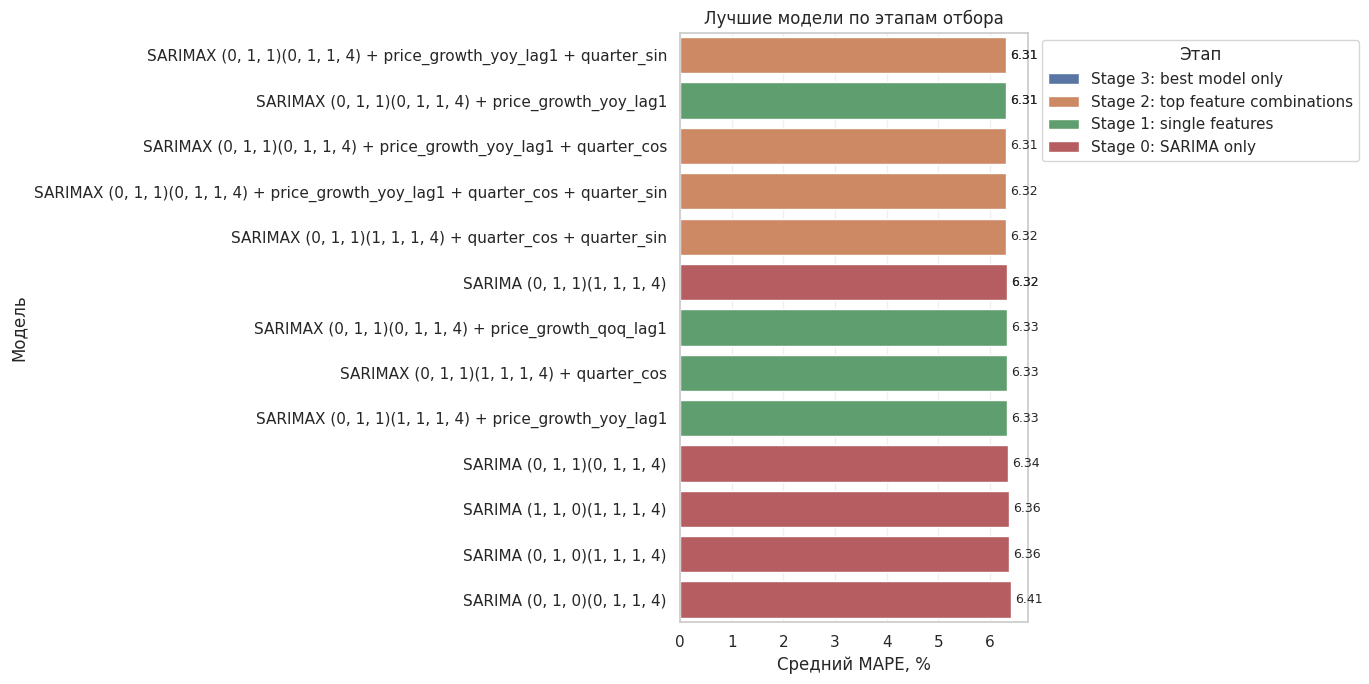

In [ ]:
plt.figure(figsize=(14, 7))

plot_stage = (
    stage_best_summary
    .sort_values("mean_MAPE")
    .copy()
)

ax = sns.barplot(
    data=plot_stage,
    x="mean_MAPE",
    y="model",
    hue="stage",
    dodge=False
)

plt.title("Лучшие модели по этапам отбора")
plt.xlabel("Средний MAPE, %")
plt.ylabel("Модель")
plt.grid(axis="x", alpha=0.3)
plt.legend(title="Этап", bbox_to_anchor=(1.02, 1), loc="upper left")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

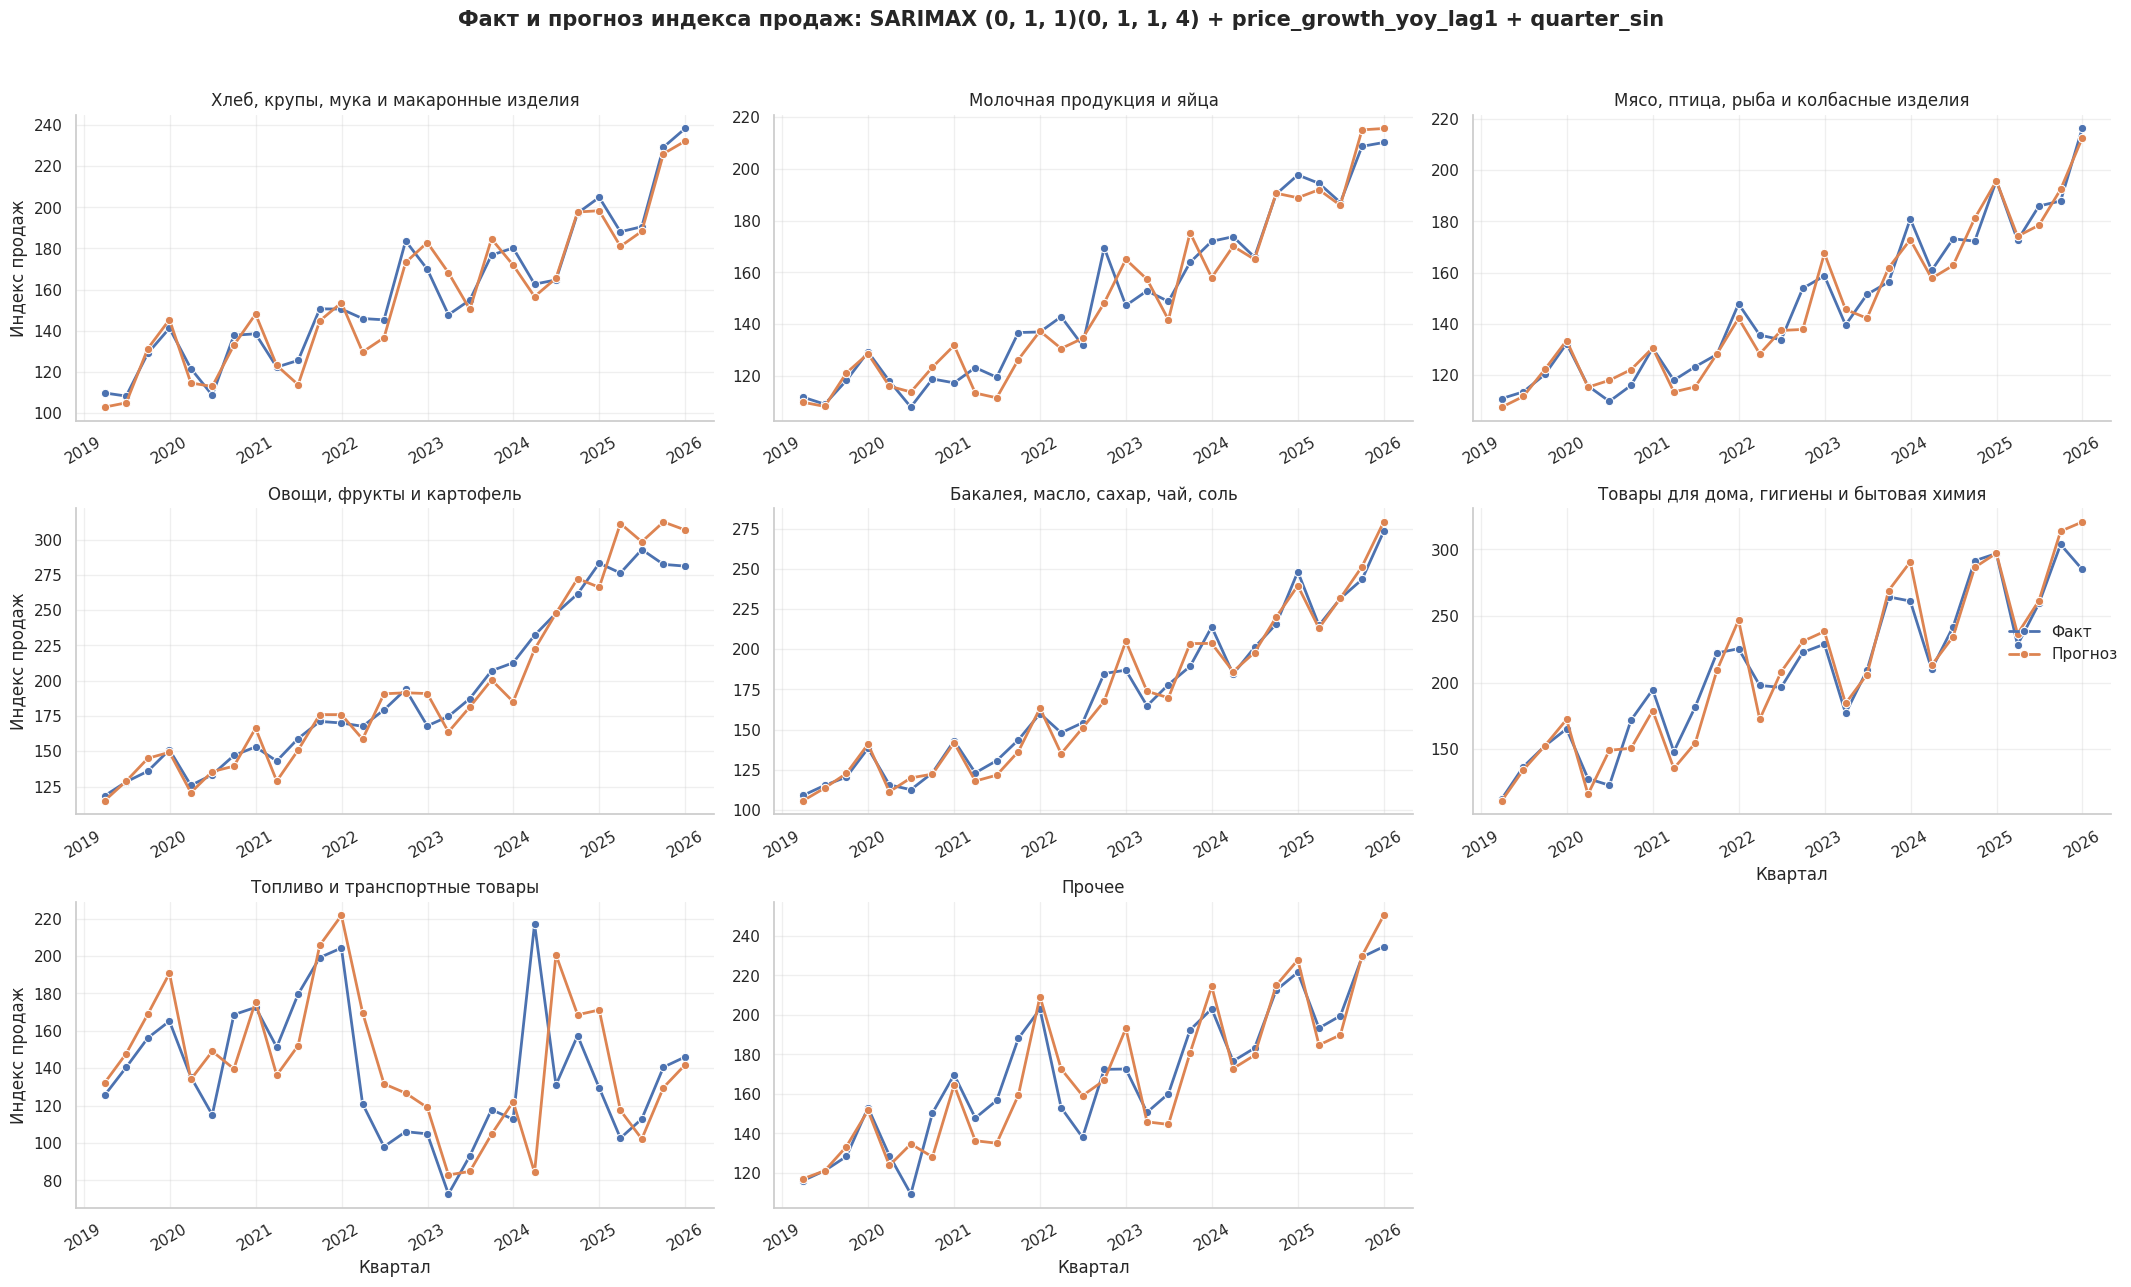

In [ ]:
plot_best = pd.concat(
    [
        stage3_predictions_df[
            [
                "period_end",
                "product_group_name",
                "y"
            ]
        ]
        .rename(columns={"y": "value"})
        .assign(series="Факт"),
        stage3_predictions_df[
            [
                "period_end",
                "product_group_name",
                "yhat"
            ]
        ]
        .rename(columns={"yhat": "value"})
        .assign(series="Прогноз")
    ],
    ignore_index=True
)

g = sns.FacetGrid(
    plot_best,
    col="product_group_name",
    col_wrap=3,
    height=4.2,
    aspect=1.6,
    hue="series",
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="period_end",
    y="value",
    marker="o",
    linewidth=2
)

g.add_legend(title="")
g.set_axis_labels("Квартал", "Индекс продаж")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Факт и прогноз индекса продаж: {BEST_MODEL_NAME}",
    y=1.02,
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

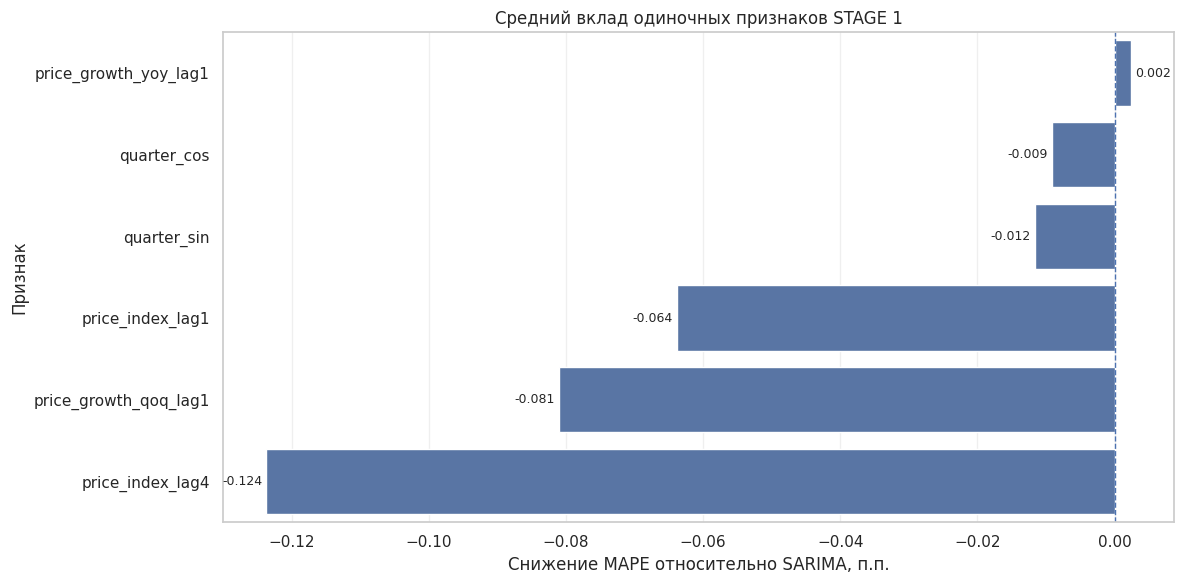

In [ ]:
plt.figure(figsize=(12, 6))

feature_plot = stage1_feature_summary.sort_values(
    "mean_feature_gain_pp",
    ascending=False
)

ax = sns.barplot(
    data=feature_plot,
    x="mean_feature_gain_pp",
    y="feature_set"
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Средний вклад одиночных признаков STAGE 1")
plt.xlabel("Снижение MAPE относительно SARIMA, п.п.")
plt.ylabel("Признак")
plt.grid(axis="x", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

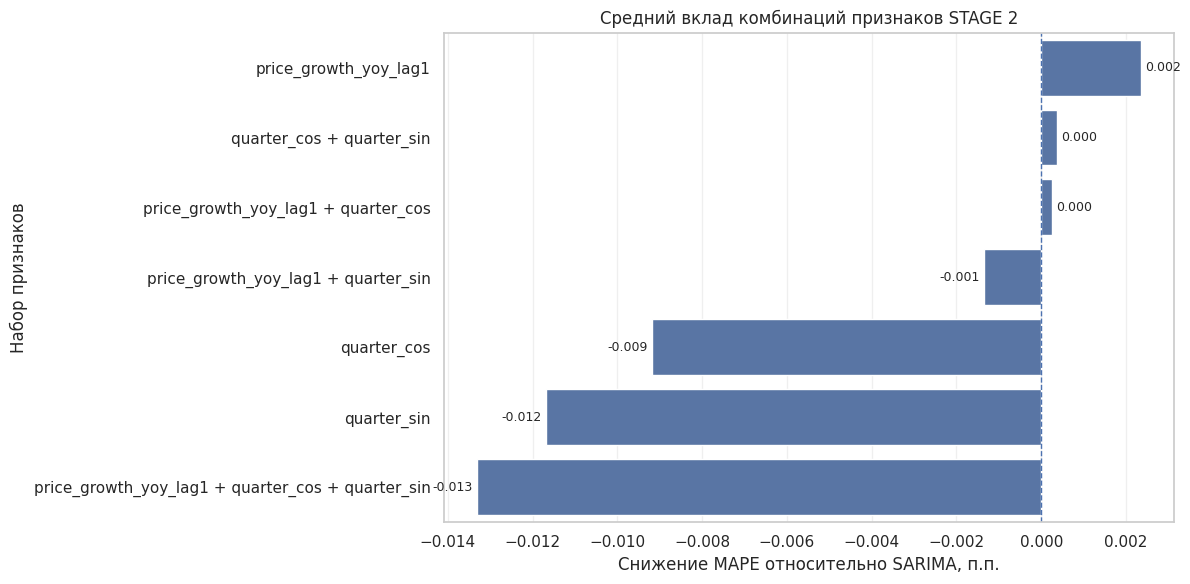

In [ ]:
plt.figure(figsize=(12, 6))

feature_plot_2 = stage2_feature_summary.sort_values(
    "mean_feature_gain_pp",
    ascending=False
)

ax = sns.barplot(
    data=feature_plot_2,
    x="mean_feature_gain_pp",
    y="feature_set"
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Средний вклад комбинаций признаков STAGE 2")
plt.xlabel("Снижение MAPE относительно SARIMA, п.п.")
plt.ylabel("Набор признаков")
plt.grid(axis="x", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
anomaly_check = stage3_predictions_df.copy()

anomaly_check["abs_error"] = (anomaly_check["y"] - anomaly_check["yhat"]).abs()
anomaly_check["pct_error"] = anomaly_check["abs_error"] / anomaly_check["y"] * 100
anomaly_check["yhat_to_y_ratio"] = anomaly_check["yhat"] / anomaly_check["y"]

display(
    anomaly_check
    .sort_values("yhat", ascending=False)
    [
        [
            "period_end",
            "year",
            "quarter",
            "product_group_code",
            "product_group_name",
            "model",
            "feature_set",
            "y",
            "yhat",
            "abs_error",
            "pct_error",
            "yhat_to_y_ratio"
        ]
    ]
    .head(30)
)

,period_end,year,quarter,product_group_code,product_group_name,model,feature_set,y,yhat,abs_error,pct_error,yhat_to_y_ratio
167,2025-12-31,2025,4,G07,"Товары для дома, гигиены и бытовая химия","SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",price_growth_yoy_lag1 + quarter_sin,284.907447,320.531325,35.623877,12.503667,1.125037
166,2025-09-30,2025,3,G07,"Товары для дома, гигиены и бытовая химия","SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",price_growth_yoy_lag1 + quarter_sin,303.638476,313.575457,9.936981,3.272636,1.032726
110,2025-09-30,2025,3,G04,"Овощи, фрукты и картофель","SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",price_growth_yoy_lag1 + quarter_sin,282.419675,312.460032,30.040357,10.636779,1.106368
108,2025-03-31,2025,1,G04,"Овощи, фрукты и картофель","SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",price_growth_yoy_lag1 + quarter_sin,276.285039,311.338748,35.053709,12.687516,1.126875
111,2025-12-31,2025,4,G04,"Овощи, фрукты и картофель","SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",price_growth_yoy_lag1 + quarter_sin,281.183722,306.828683,25.644961,9.120358,1.091204
109,2025-06-30,2025,2,G04,"Овощи, фрукты и картофель","SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",price_growth_yoy_lag1 + quarter_sin,292.921975,298.451053,5.529078,1.887560,1.018876
163,2024-12-31,2024,4,G07,"Товары для дома, гигиены и бытовая химия","SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",price_growth_yoy_lag1 + quarter_sin,296.831992,297.086041,0.254049,0.085587,1.000856
159,2023-12-31,2023,4,G07,"Товары для дома, гигиены и бытовая химия","SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",price_growth_yoy_lag1 + quarter_sin,261.190114,290.579859,29.389746,11.252243,1.112522
162,2024-09-30,2024,3,G07,"Товары для дома, гигиены и бытовая химия","SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",price_growth_yoy_lag1 + quarter_sin,291.444751,286.442715,5.002036,1.716290,0.982837
139,2025-12-31,2025,4,G05,"Бакалея, масло, сахар, чай, соль","SARIMAX (0, 1, 1)(0, 1, 1, 4) + price_growth_y...",price_growth_yoy_lag1 + quarter_sin,273.155201,279.070883,5.915682,2.165685,1.021657


In [ ]:
display(
    anomaly_check
    .groupby(["year", "quarter"], as_index=False)
    .agg(
        mean_MAPE=("pct_error", "mean"),
        median_MAPE=("pct_error", "median"),
        max_MAPE=("pct_error", "max"),
        mean_y=("y", "mean"),
        mean_yhat=("yhat", "mean"),
        max_yhat=("yhat", "max"),
        n=("pct_error", "size")
    )
    .sort_values("max_MAPE", ascending=False)
    .head(20)
)

,year,quarter,mean_MAPE,median_MAPE,max_MAPE,mean_y,mean_yhat,max_yhat,n
20,2024,1,9.700374,2.119393,61.177313,189.710529,170.348802,222.171393,8
21,2024,2,8.342664,1.776528,53.074546,188.588653,194.197775,247.729584,8
12,2022,1,13.166752,9.965664,40.364238,151.486572,149.624650,172.661987,8
13,2022,2,9.355112,5.978993,34.279442,147.083752,156.123764,208.014935,8
23,2024,4,6.545742,3.333468,32.217066,222.198390,223.073383,297.086041,8
5,2020,2,12.371818,6.991848,29.470880,114.956329,129.126376,149.173851,8
14,2022,3,8.205196,7.513267,19.465629,173.354482,167.846809,230.917873,8
6,2020,3,7.832759,5.231742,17.174725,141.686526,132.338711,150.661246,8
3,2019,4,3.511843,1.497407,15.504148,146.952125,151.540279,190.730436,8
9,2021,2,9.825868,8.164381,15.320611,147.016136,131.864565,154.614213,8


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr

OUT_DIR = Path("/content/drive/MyDrive/rostat/demand_forecast_2025")
GIFFEN_DIR = OUT_DIR / "giffen_test"
GIFFEN_DIR.mkdir(parents=True, exist_ok=True)

# Товарные группы. G11 исключаем, потому что это услуги.
# G10 можно добавить отдельно, если хочешь тестировать топливо.
GIFFEN_TEST_GROUPS = ["G01", "G02", "G03", "G04", "G05", "G07", "G99"]

ALPHA = 0.10  # уровень значимости: 10%, можно заменить на 0.05

# ------------------------------------------------------------
# 1. Подготовка переменных
# ------------------------------------------------------------

df = quarterly_data[
    quarterly_data["product_group_code"].isin(GIFFEN_TEST_GROUPS)
].copy()

df = df.sort_values(["product_group_code", "period_end"]).reset_index(drop=True)

# Если real_sales_proxy_index_filled ещё не создан, создаём его.
if "real_sales_proxy_index_filled" not in df.columns:
    if "price_index_filled" not in df.columns:
        df["price_index_filled"] = (
            df
            .groupby("product_group_code")["price_index"]
            .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
        )

    df["real_sales_proxy_filled"] = (
        df["sales_index"] / df["price_index_filled"] * 100
    )

    def make_index_from_first_valid(x):
        x = x.astype(float)
        valid = x.dropna()
        if len(valid) == 0:
            return pd.Series(np.nan, index=x.index)
        base = valid.iloc[0]
        if pd.isna(base) or base == 0:
            return pd.Series(np.nan, index=x.index)
        return x / base * 100

    df["real_sales_proxy_index_filled"] = (
        df
        .groupby("product_group_code")["real_sales_proxy_filled"]
        .transform(make_index_from_first_valid)
    )

# Основная зависимая переменная для теста:
# наблюдаемый физический proxy объём, а не уже скорректированный спрос.
df["q_obs_proxy"] = df["real_sales_proxy_index_filled"]

# Цена
if "price_index_filled" not in df.columns:
    df["price_index_filled"] = (
        df
        .groupby("product_group_code")["price_index"]
        .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
    )

df["log_q"] = np.log(df["q_obs_proxy"].clip(lower=1e-6))
df["log_price"] = np.log((df["price_index_filled"] / 100).clip(lower=1e-6))

# Тренд
df["time_idx"] = df.groupby("product_group_code").cumcount()

# Дефицит запасов, если есть stock_days_mean
if "stock_days_mean" in df.columns:
    pre_shock = df["year"].between(2017, 2021)

    normal_stock = (
        df.loc[pre_shock]
        .groupby("product_group_code")["stock_days_mean"]
        .median()
        .to_dict()
    )

    df["normal_stock_days"] = df["product_group_code"].map(normal_stock)
    df["stock_shortage"] = (
        df["normal_stock_days"] - df["stock_days_mean"]
    ).clip(lower=0)
else:
    df["stock_shortage"] = 0.0

# Event-флаги, если их нет
if "shock_2022_q1" not in df.columns:
    df["shock_2022_q1"] = ((df["year"] == 2022) & (df["quarter"] == 1)).astype(int)

if "shock_2022_q2" not in df.columns:
    df["shock_2022_q2"] = ((df["year"] == 2022) & (df["quarter"] == 2)).astype(int)

if "shock_2022_h2" not in df.columns:
    df["shock_2022_h2"] = ((df["year"] == 2022) & (df["quarter"].isin([3, 4]))).astype(int)

if "post_2022" not in df.columns:
    df["post_2022"] = (df["period_end"] >= pd.Timestamp("2022-03-31")).astype(int)

# ------------------------------------------------------------
# 2. Ищем переменную дохода, если она есть
# ------------------------------------------------------------

possible_income_cols = [
    "real_income_index",
    "real_disposable_income_index",
    "income_index",
    "real_income",
    "real_wage_index",
]

income_col = None
for col in possible_income_cols:
    if col in df.columns and df[col].notna().sum() >= 20:
        income_col = col
        break

if income_col is not None:
    df["log_income"] = np.log(df[income_col].clip(lower=1e-6))
    print("Используется переменная дохода:", income_col)
else:
    print("Переменная дохода не найдена. Будет проверяться только положительная ценовая эластичность.")

NameError: name 'quarterly_data' is not defined

In [ ]:
# ============================================================
# 3. Регрессионный тест Гиффена по каждой категории
# ============================================================

giffen_rows = []
residual_plot_data = []

for group_code, g in df.groupby("product_group_code"):
    g = g.copy().sort_values("period_end")

    base_cols = [
        "log_q",
        "log_price",
        "stock_shortage",
        "time_idx",
        "quarter",
        "shock_2022_q1",
        "shock_2022_q2",
        "shock_2022_h2",
        "post_2022",
    ]

    if income_col is not None:
        base_cols.append("log_income")

    model_data = g[base_cols].dropna().copy()

    if len(model_data) < 20:
        giffen_rows.append({
            "Код группы": group_code,
            "Название группы": g["product_group_name"].iloc[0],
            "Статус": "Недостаточно данных",
            "Число наблюдений": len(model_data),
            "Ценовая эластичность β": np.nan,
            "p-value β": np.nan,
            "Доходная эластичность γ": np.nan,
            "p-value γ": np.nan,
            "R²": np.nan,
            "Spearman price-volume": np.nan,
            "Вывод": "Недостаточно данных для проверки",
        })
        continue

    X_cols = [
        "log_price",
        "stock_shortage",
        "time_idx",
        "shock_2022_q1",
        "shock_2022_q2",
        "shock_2022_h2",
        "post_2022",
    ]

    if income_col is not None:
        X_cols.append("log_income")

    X = model_data[X_cols].copy()

    quarter_dummies = pd.get_dummies(
        model_data["quarter"].astype(int),
        prefix="Q",
        drop_first=True
    )

    X = pd.concat([X, quarter_dummies], axis=1)
    X = sm.add_constant(X, has_constant="add")

    y = model_data["log_q"]

    result = sm.OLS(y, X).fit(cov_type="HC3")

    beta_price = result.params.get("log_price", np.nan)
    beta_price_pvalue = result.pvalues.get("log_price", np.nan)

    if income_col is not None:
        gamma_income = result.params.get("log_income", np.nan)
        gamma_income_pvalue = result.pvalues.get("log_income", np.nan)
    else:
        gamma_income = np.nan
        gamma_income_pvalue = np.nan

    # Простая корреляционная проверка без контролей
    corr_data = g[["log_price", "log_q"]].dropna()
    if len(corr_data) >= 5:
        spearman_corr, spearman_p = spearmanr(corr_data["log_price"], corr_data["log_q"])
    else:
        spearman_corr, spearman_p = np.nan, np.nan

    # Логика классификации
    price_positive_significant = (
        pd.notna(beta_price)
        and beta_price > 0
        and pd.notna(beta_price_pvalue)
        and beta_price_pvalue <= ALPHA
    )

    price_positive_weak = (
        pd.notna(beta_price)
        and beta_price > 0
        and not price_positive_significant
    )

    if income_col is not None:
        income_negative = pd.notna(gamma_income) and gamma_income < 0
        income_negative_significant = (
            income_negative
            and pd.notna(gamma_income_pvalue)
            and gamma_income_pvalue <= ALPHA
        )

        if price_positive_significant and income_negative_significant:
            conclusion = "Сильный кандидат в товары Гиффена"
            status = "strong_giffen_candidate"
        elif price_positive_significant and income_negative:
            conclusion = "Кандидат: цена положительная, доход отрицательный, но доход слабозначим"
            status = "possible_giffen_candidate"
        elif price_positive_significant:
            conclusion = "Гиффеноподобное поведение по цене, но доходный критерий не подтверждён"
            status = "price_giffen_like_only"
        elif price_positive_weak:
            conclusion = "Слабый положительный ценовой эффект, статистически не подтверждён"
            status = "weak_positive_price_effect"
        else:
            conclusion = "Признаков товара Гиффена не найдено"
            status = "not_giffen"
    else:
        if price_positive_significant:
            conclusion = "Гиффеноподобное поведение по цене; доходный критерий не проверен"
            status = "price_giffen_like_only"
        elif price_positive_weak:
            conclusion = "Слабый положительный ценовой эффект, статистически не подтверждён"
            status = "weak_positive_price_effect"
        else:
            conclusion = "Признаков товара Гиффена не найдено"
            status = "not_giffen"

    giffen_rows.append({
        "Код группы": group_code,
        "Название группы": g["product_group_name"].iloc[0],
        "Статус": status,
        "Число наблюдений": len(model_data),
        "Ценовая эластичность β": beta_price,
        "p-value β": beta_price_pvalue,
        "Доходная эластичность γ": gamma_income,
        "p-value γ": gamma_income_pvalue,
        "R²": result.rsquared,
        "Spearman price-volume": spearman_corr,
        "Spearman p-value": spearman_p,
        "Вывод": conclusion,
    })

    # Данные для диагностического графика:
    # остатки Q без цены против остатков цены без контролей.
    controls_cols = [
        c for c in X.columns
        if c not in ["const", "log_price"]
    ]

    X_controls = sm.add_constant(X[controls_cols], has_constant="add")

    y_resid = sm.OLS(y, X_controls).fit().resid
    price_resid = sm.OLS(model_data["log_price"], X_controls).fit().resid

    tmp = pd.DataFrame({
        "product_group_code": group_code,
        "product_group_name": g["product_group_name"].iloc[0],
        "price_resid": price_resid,
        "q_resid": y_resid,
    })

    residual_plot_data.append(tmp)

giffen_results = pd.DataFrame(giffen_rows)

giffen_results = giffen_results.sort_values(
    by=["Статус", "Ценовая эластичность β"],
    ascending=[True, False]
)

display(giffen_results)

giffen_results.to_csv(
    GIFFEN_DIR / "проверка_товаров_гиффена_по_категориям.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Сохранено:", GIFFEN_DIR / "проверка_товаров_гиффена_по_категориям.csv")

In [ ]:
# ============================================================
# 4. Визуализация результатов
# ============================================================

import math
from textwrap import fill

# 4.1. Барчарт ценовой эластичности
plot_df = giffen_results.copy()
plot_df = plot_df.dropna(subset=["Ценовая эластичность β"])

plt.figure(figsize=(12, 6))

colors = [
    "tab:red" if row["Ценовая эластичность β"] > 0 and row["p-value β"] <= ALPHA
    else "tab:orange" if row["Ценовая эластичность β"] > 0
    else "tab:blue"
    for _, row in plot_df.iterrows()
]

labels = [
    fill(name, width=28)
    for name in plot_df["Название группы"]
]

plt.barh(labels, plot_df["Ценовая эластичность β"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Проверка Гиффеноподобного поведения: ценовая эластичность по категориям")
plt.xlabel("Оценка β при log(price)")
plt.ylabel("Категория")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(GIFFEN_DIR / "ценовая_эластичность_по_категориям.png", dpi=160)
plt.show()


# 4.2. Scatter residual plot на одном холсте
if len(residual_plot_data) > 0:
    residual_df = pd.concat(residual_plot_data, ignore_index=True)

    groups = (
        residual_df[["product_group_code", "product_group_name"]]
        .drop_duplicates()
        .sort_values("product_group_name")
    )

    n_groups = len(groups)
    ncols = 2
    nrows = math.ceil(n_groups / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, groups.iterrows()):
        group_code = row["product_group_code"]
        group_name = row["product_group_name"]

        g = residual_df[residual_df["product_group_code"] == group_code].copy()

        ax.scatter(g["price_resid"], g["q_resid"], alpha=0.75)

        if len(g) >= 2:
            z = np.polyfit(g["price_resid"], g["q_resid"], 1)
            x_line = np.linspace(g["price_resid"].min(), g["price_resid"].max(), 50)
            y_line = z[0] * x_line + z[1]
            ax.plot(x_line, y_line, linewidth=2)

        ax.axhline(0, color="black", linewidth=0.8)
        ax.axvline(0, color="black", linewidth=0.8)

        metric_row = giffen_results[giffen_results["Код группы"] == group_code]
        if len(metric_row) > 0:
            beta = metric_row["Ценовая эластичность β"].iloc[0]
            pval = metric_row["p-value β"].iloc[0]
            ax.text(
                0.02,
                0.95,
                f"β = {beta:.3f}\np = {pval:.3f}",
                transform=ax.transAxes,
                va="top",
                fontsize=10,
                bbox=dict(boxstyle="round", alpha=0.15)
            )

        ax.set_title(fill(group_name, width=35))
        ax.set_xlabel("Остаток log(price) после контролей")
        ax.set_ylabel("Остаток log(quantity) после контролей")
        ax.grid(True, alpha=0.3)

    for j in range(n_groups, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        "Partial regression: связь цены и объёма после контроля сезонности, тренда и шоков",
        fontsize=15
    )
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(GIFFEN_DIR / "partial_regression_price_quantity.png", dpi=160)
    plt.show()

NameError: name 'giffen_results' is not defined